In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

from sklearn.metrics import mean_squared_error, r2_score , root_mean_squared_error
from scipy.stats import pearsonr

# Hellper functions

In [18]:
def opening_files(file_name, lighting = 'light'):
        dir_ = 'python_format'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat
# rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')

rand2 = np.load('rat2_rand.npz' , allow_pickle=True)
# rand2 = np.load('fake_rat2_all.npz' , allow_pickle=True)

mod1 = rand2['grid_mod1']
mod2 = rand2['grid_mod2']
mod3 = rand2['grid_mod3']

# to get your original dict back:
grid_mod1_dict = mod1.item()
grid_mod2_dict = mod2.item()
grid_mod3_dict = mod3.item()

rand2_clean={'grid_mod1': grid_mod1_dict,
             'grid_mod2': grid_mod2_dict,
             'grid_mod3': grid_mod3_dict,
             't' : rand2['t'],
             'x' : rand2['x'],
             'y' : rand2['y'],
}
this_rat = rand2_clean
this_rat = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')
    

In [19]:
def predict_positions_with_cv(features, targets, t_steps, future=True, regressor='linear', n_splits=4):
    """
    Predicts positions t steps into the future or past based on current neural data,
    using n-fold cross-validation.
    
    Args:
    features (np.ndarray): The neural feature matrix.
    targets (np.ndarray): The matrix of target positions.
    t_steps (int): Number of steps to predict into the future or past.
    future (bool): If True, predict future; otherwise, predict past.
    n_splits (int): Number of folds for cross-validation.
    
    Returns:
    float: Average MSE across the cross-validation folds.
    """
    if future:
        # Future Prediction: shift targets up and set last t_steps rows to NaN
        y_shifted = np.roll(targets, -t_steps, axis=0)
        y_shifted[-t_steps:] = np.nan
    else:
        # Past Prediction: shift targets down and set first t_steps rows to NaN
        y_shifted = np.roll(targets, t_steps, axis=0)
        y_shifted[:t_steps] = np.nan

    # Remove NaN entries
    valid_indices = ~np.isnan(y_shifted).any(axis=1)
    X_valid = features[valid_indices]
    y_valid = y_shifted[valid_indices]
    
    # Cross-validation setup
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_scores = []
    corr_scores = []

    for train_index, test_index in kf.split(X_valid):
        X_train, X_test = X_valid[train_index], X_valid[test_index]
        y_train, y_test = y_valid[train_index], y_valid[test_index]
        
        if regressor=='forest':
            model = RandomForestRegressor()
#             model = RandomForestRegressor(
#                 n_estimators=200,
#                 max_depth=10,
#                 min_samples_split=4,
#                 min_samples_leaf=2,
#                 max_features='sqrt',
#                 random_state=42,
#                 bootstrap=True
#             )
            
        else:
            model = LinearRegression()

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # mse = mean_squared_error(y_test, y_pred)
        mse = root_mean_squared_error(y_test, y_pred)
        mse_scores.append(mse)
        
        # plt.plot(model.coef_[0])

        # Compute Pearson correlation for each dimension (x and y)
        corr_x = pearsonr(y_test[:, 0], y_pred[:, 0])[0] if y_test.shape[1] > 1 else 0
        corr_y = pearsonr(y_test[:, 1], y_pred[:, 1])[0] if y_test.shape[1] > 1 else 0
        corr_scores.append((corr_x + corr_y) / 2)  # Average correlation across dimensions

    
    return np.mean(mse_scores), np.mean(corr_scores)

In [20]:
def plot_steps(features, targets, max_range = 101, step = 10):
    mse_future = []
    corr_future = []
    mse_past = []
    corr_past = []

    for t in range(1, max_range, step):
        mse_f, corr_f = predict_positions_with_cv(features, targets, t, future=True)
        mse_p, corr_p = predict_positions_with_cv(features, targets, t, future=False)
        mse_future.append(np.sqrt(mse_f))
        corr_future.append(corr_f)
        mse_past.append(np.sqrt(mse_p))
        corr_past.append(corr_p)

    # Plot results (MSE and Correlation separately)
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_range, step), mse_future, label='Future RMSE', color='blue')
    plt.plot(range(1, max_range, step), mse_past, label='Past RMSE', color='orange')
    plt.title('Root Mean Squared Error for Future and Past Predictions')
    plt.xlabel('Time Steps (s)')
    plt.ylabel('RMSE')
    # plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_range, step), corr_future, label='Future Correlation', color='blue')
    plt.plot(range(1, max_range, step), corr_past, label='Past Correlation', color='orange')
    plt.title('Correlation for Future and Past Predictions')
    plt.xlabel('Time Steps (s)')
    plt.ylabel('Correlation Coefficient')
    # plt.legend()

    plt.tight_layout()
    # plt.show()


Mean Squared Error: 658.2978210169297


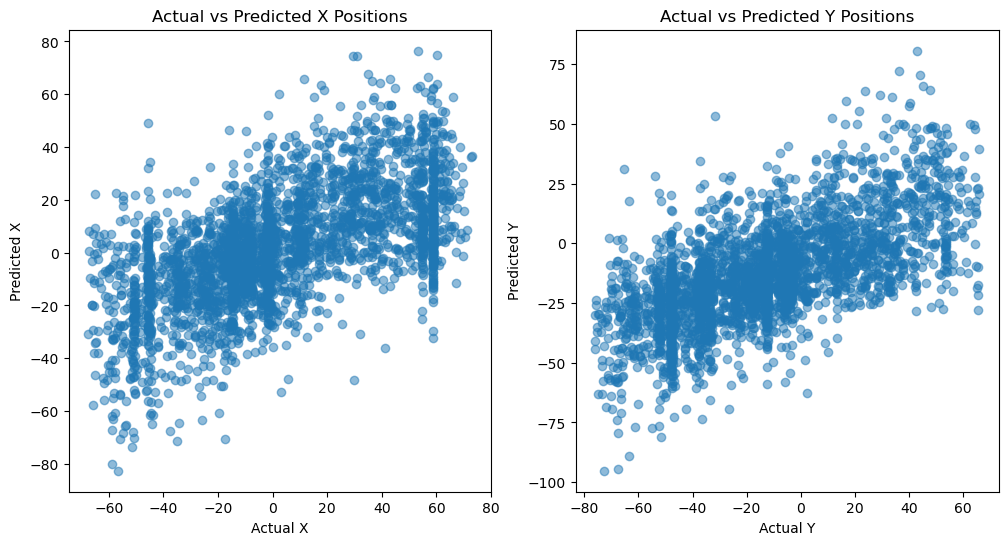

In [5]:
def create_feature_matrix(modules, t_data):
    bin_size = 0.25  # Define the size of each time bin
    t_bins = np.arange(t_data[0], t_data[-1] + bin_size, bin_size)
    # Calculate the total number of neurons across all modules
    total_neurons = sum(len(neurons) for neurons in modules.values())
    binned_spikes = np.zeros((len(t_bins) - 1, total_neurons))
    
    neuron_index = 0
    # Process each module's neurons
    for module in modules.values():
        for spikes in module.values():
            # Histogram each neuron's spikes into bins
            neuron_spike_counts = np.histogram(spikes, bins=t_bins)[0]
            binned_spikes[:, neuron_index] = neuron_spike_counts
            neuron_index += 1

    return t_bins[:-1], binned_spikes

# Assuming this_rat['grid_mod1'], this_rat['grid_mod2'], and this_rat['grid_mod3'] are properly structured
all_modules = {'mod1': this_rat['grid_mod1'], 'mod2': this_rat['grid_mod2'], 'mod3': this_rat['grid_mod3']}
t_bins, features = create_feature_matrix(all_modules, this_rat['t'])

# Interpolate 'x' and 'y' positions to the binned time points
x_interp = np.interp(t_bins, this_rat['t'], this_rat['x'])
y_interp = np.interp(t_bins, this_rat['t'], this_rat['y'])
targets = np.column_stack((x_interp, y_interp))

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.25, random_state=42)

# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate and print mean squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Visualization of actual vs predicted positions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5)
ax1.set_title('Actual vs Predicted X Positions')
ax1.set_xlabel('Actual X')
ax1.set_ylabel('Predicted X')

ax2.scatter(y_test[:, 1], y_pred[:, 1], alpha=0.5)
ax2.set_title('Actual vs Predicted Y Positions')
ax2.set_xlabel('Actual Y')
ax2.set_ylabel('Predicted Y')
plt.show()


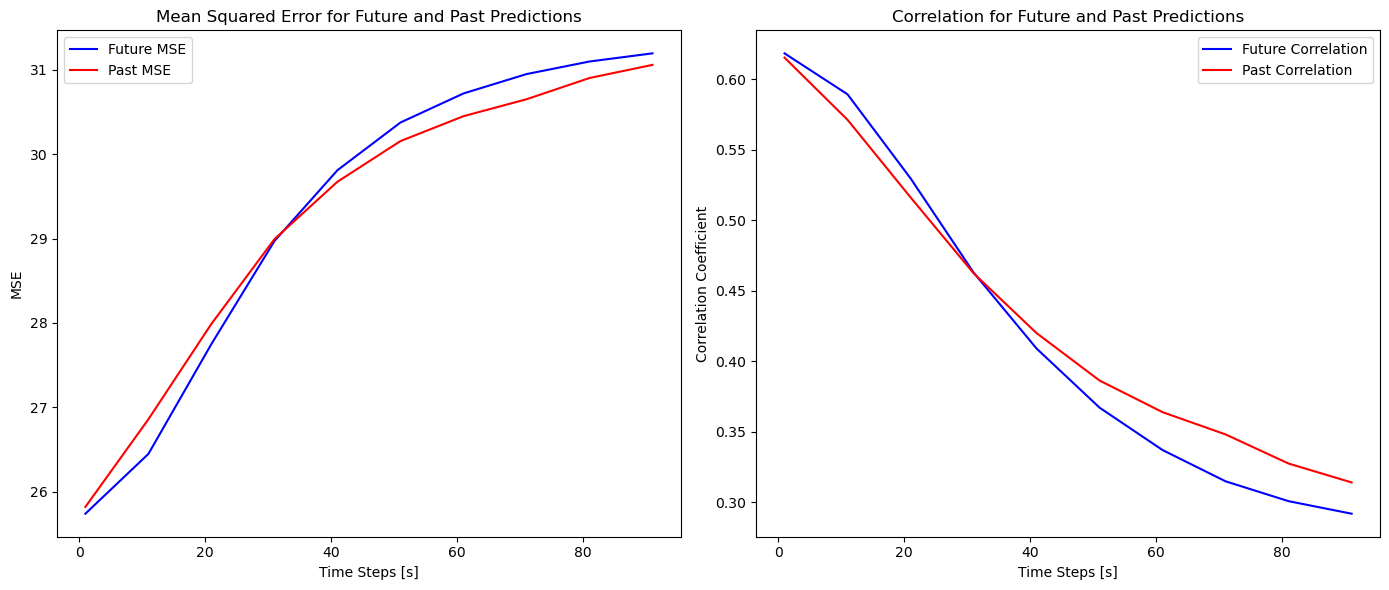

In [6]:


# Loop to collect average MSE for future and past predictions from 1 to 100 steps
# Example loop usage
max_range = 101
step = 10
mse_future = []
corr_future = []
mse_past = []
corr_past = []

for t in range(1, max_range, step):
    mse_f, corr_f = predict_positions_with_cv(features, targets, t, future=True)
    mse_p, corr_p = predict_positions_with_cv(features, targets, t, future=False)
    mse_future.append(np.sqrt(mse_f))
    corr_future.append(corr_f)
    mse_past.append(np.sqrt(mse_p))
    corr_past.append(corr_p)

# Plot results (MSE and Correlation separately)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, max_range, step), mse_future, label='Future MSE', color='blue')
plt.plot(range(1, max_range, step), mse_past, label='Past MSE', color='red')
plt.title('Mean Squared Error for Future and Past Predictions')
plt.xlabel('Time Steps [s]')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, max_range, step), corr_future, label='Future Correlation', color='blue')
plt.plot(range(1, max_range, step), corr_past, label='Past Correlation', color='red')
plt.title('Correlation for Future and Past Predictions')
plt.xlabel('Time Steps [s]')
plt.ylabel('Correlation Coefficient')
plt.legend()

plt.tight_layout()
plt.show()


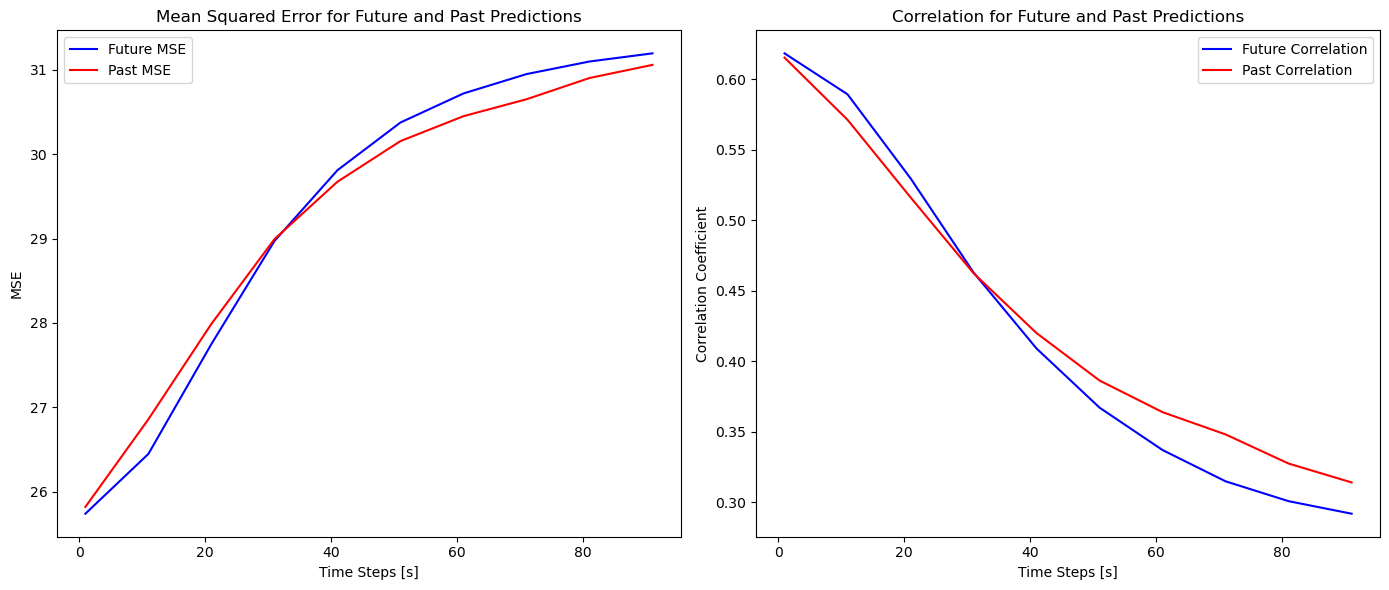

In [ ]:


# Loop to collect average MSE for future and past predictions from 1 to 100 steps
# Example loop usage
max_range = 101
step = 10
mse_future = []
corr_future = []
mse_past = []
corr_past = []

for t in range(1, max_range, step):
    mse_f, corr_f = predict_positions_with_cv(features, targets, t, future=True)
    mse_p, corr_p = predict_positions_with_cv(features, targets, t, future=False)
    mse_future.append(np.sqrt(mse_f))
    corr_future.append(corr_f)
    mse_past.append(np.sqrt(mse_p))
    corr_past.append(corr_p)

# Plot results (MSE and Correlation separately)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, max_range, step), mse_future, label='Future MSE', color='blue')
plt.plot(range(1, max_range, step), mse_past, label='Past MSE', color='red')
plt.title('Mean Squared Error for Future and Past Predictions')
plt.xlabel('Time Steps [s]')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, max_range, step), corr_future, label='Future Correlation', color='blue')
plt.plot(range(1, max_range, step), corr_past, label='Past Correlation', color='red')
plt.title('Correlation for Future and Past Predictions')
plt.xlabel('Time Steps [s]')
plt.ylabel('Correlation Coefficient')
plt.legend()

plt.tight_layout()
plt.show()


# Plots

In [15]:
rat1 = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'light')
rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'light')
rat3 = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'light')
rat4 = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'light')
rat5 = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'light')

rat1_dark = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'dark')
rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')
rat3_dark = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'dark')
rat4_dark = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'dark')
rat5_dark = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'dark')

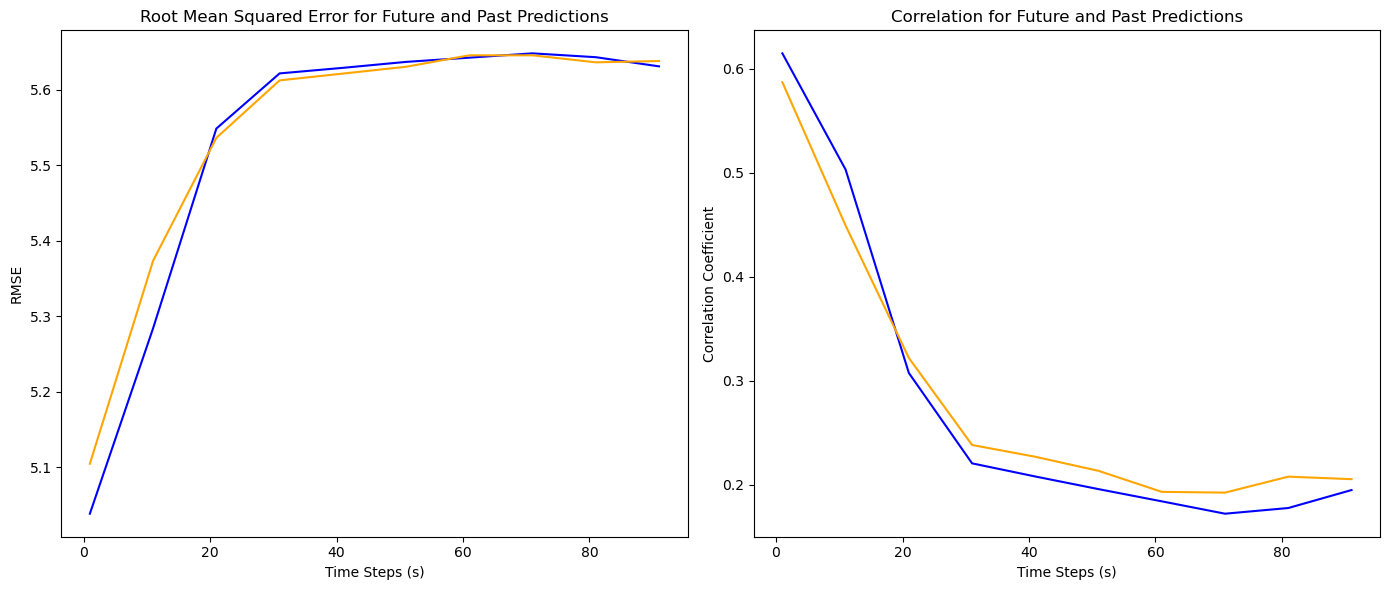

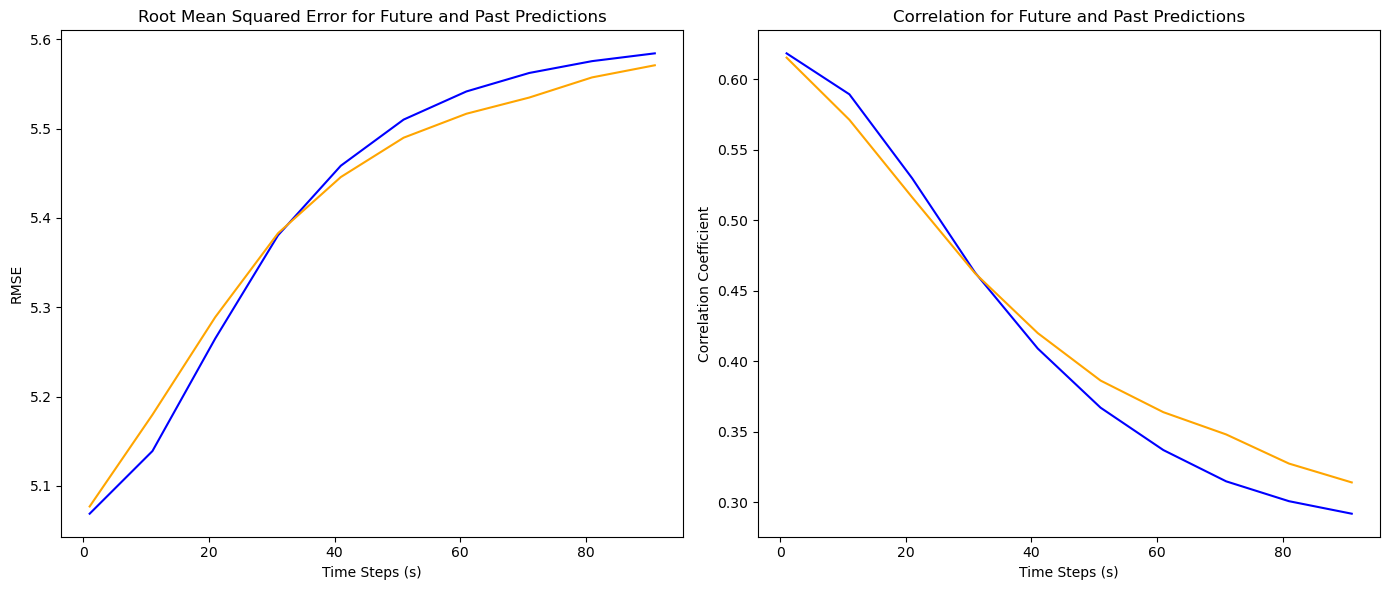

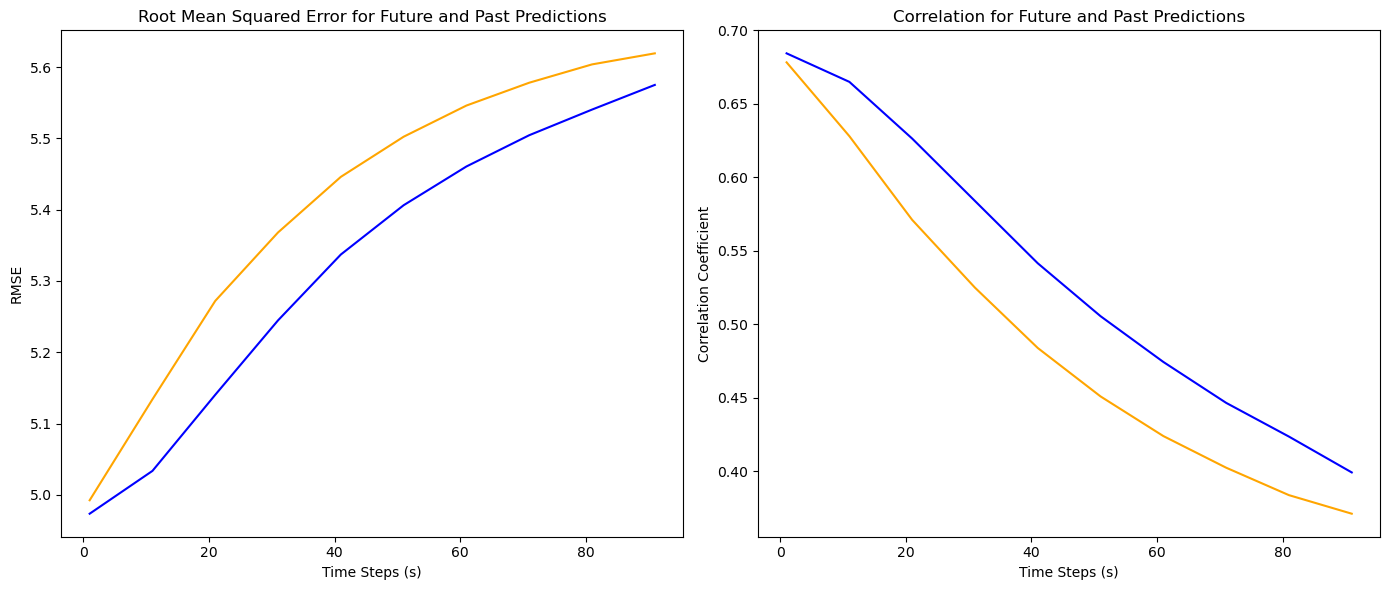

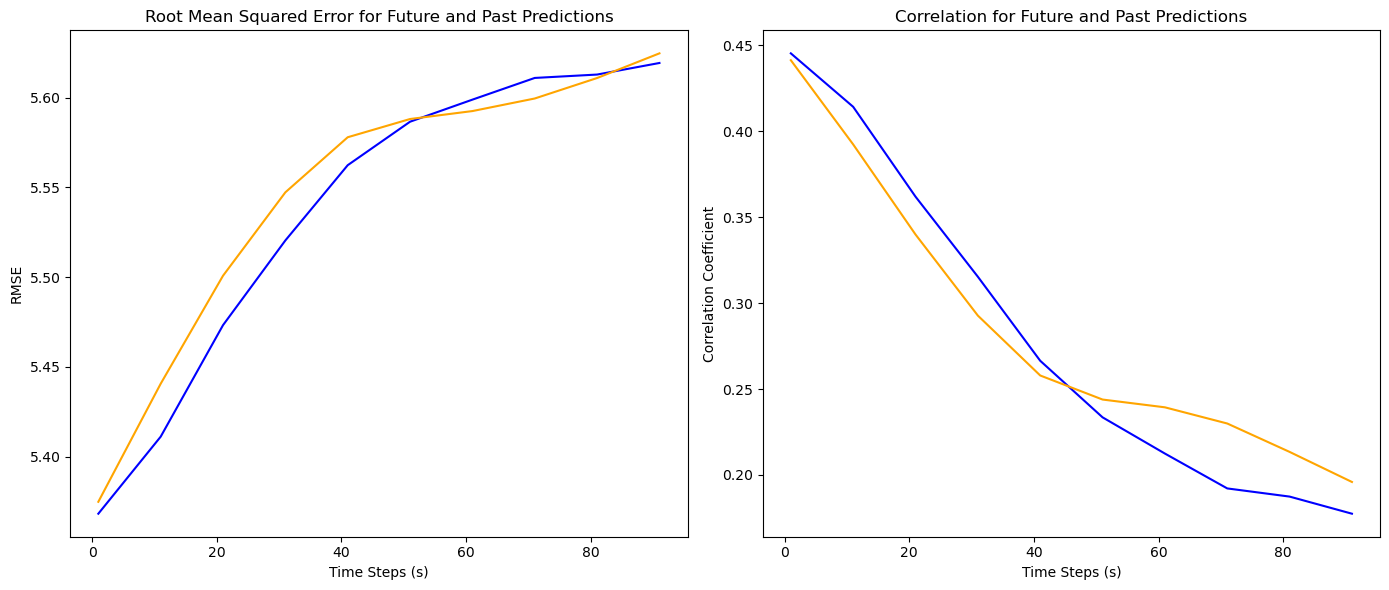

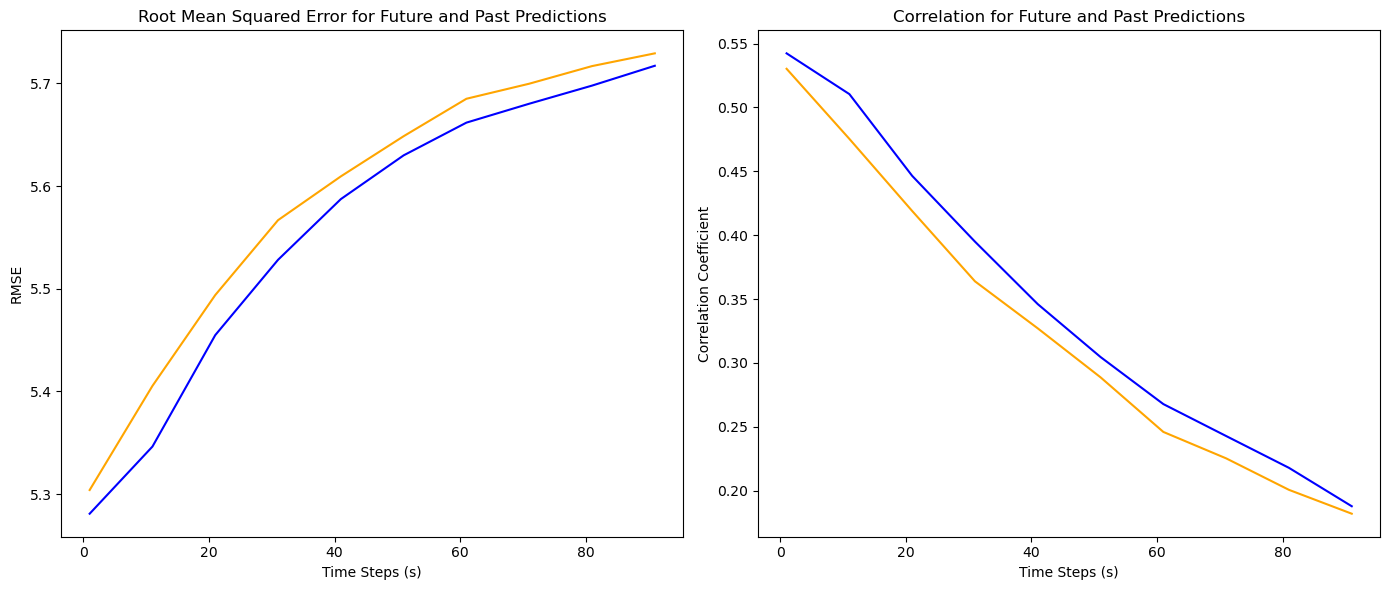

In [22]:
# file_names = ['rat1', 'rat2', 'rat3', 'rat4', 'rat5']
# for i_ , this_rat in enumerate( [rat1, rat2, rat3, rat4, rat5]):
file_names = ['rat1_dark', 'rat2_dark', 'rat3_dark', 'rat4_dark', 'rat5_dark']
for i_ , this_rat in enumerate([rat1_dark, rat2_dark, rat3_dark, rat4_dark, rat5_dark]):
    all_modules = {'mod1': this_rat['grid_mod1'], 'mod2': this_rat['grid_mod2'], 'mod3': this_rat['grid_mod3']}
    t_bins, features = create_feature_matrix(all_modules, this_rat['t'])

    # Interpolate 'x' and 'y' positions to the binned time points
    x_interp = np.interp(t_bins, this_rat['t'], this_rat['x'])
    y_interp = np.interp(t_bins, this_rat['t'], this_rat['y'])
    targets = np.column_stack((x_interp, y_interp))
    plot_steps(features , targets)
    plt.savefig(f'./qulas_plot/regression_{file_names[i_]}.png')
